In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"/kaggle/input/upi-transactions-2024-dataset/upi_transactions_2024.csv")
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [2]:
for col in df:
    print(df[col].name)
    print(df[col].unique())
    print("Count: ", df[col].size)
    print("-" * 75)

transaction id
['TXN0000000001' 'TXN0000000002' 'TXN0000000003' ... 'TXN0000249998'
 'TXN0000249999' 'TXN0000250000']
Count:  250000
---------------------------------------------------------------------------
timestamp
['2024-10-08 15:17:28' '2024-04-11 06:56:00' '2024-04-02 13:27:18' ...
 '2024-11-27 16:33:25' '2024-01-05 13:31:30' '2024-01-17 15:23:07']
Count:  250000
---------------------------------------------------------------------------
transaction type
['P2P' 'P2M' 'Bill Payment' 'Recharge']
Count:  250000
---------------------------------------------------------------------------
merchant_category
['Entertainment' 'Grocery' 'Fuel' 'Shopping' 'Food' 'Other' 'Utilities'
 'Transport' 'Healthcare' 'Education']
Count:  250000
---------------------------------------------------------------------------
amount (INR)
[  868  1011   477 ... 14456 11576  9505]
Count:  250000
---------------------------------------------------------------------------
transaction_status
['SUCCESS' 'FAILED

# Dataset study
This is a dataset of 250,000 sample transactions done by users via UPI (Unified Payments Interface) containing multiple parameters to evaluate the purchasing behaviour, fraud patterns, payments analysis, etc.
1. transaction id - unique identifier for each transactions
2. timestamp - date and time of transaction taking place
3. transaction type - there are 4 types of transactions - P2P (Person to person), P2M (Person to Merchent), Bill Payment, and Recharge
4. merchant_category - the type of merchent registered
5. amount - the value of payment
6. transaction_status - containing only 2 values telling if the payment was successful or not
7. sender_age_group - age groups of all the senders
8. receiver_age_group - age groups of all the receivers
9. sender_state - the states from which the sender is sending the payments
10. sender_bank - the bank from which the payment is made
11. receiver_bank - the bank in which the payment is received
12. device_type - the device used to send payment
13. network type - which type of network is used
14. fraud_flag - a column telling if the payment category falls under fraud category or not
15. hour_of_day - at which hour the payment is made
16. day_of_week - the day on which the payment was made
17. is_weekend - if the day is weekend or not

In [3]:
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [4]:
df.dtypes
#timestamp is object type and can be converted to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.dtypes

transaction id                object
timestamp             datetime64[ns]
transaction type              object
merchant_category             object
amount (INR)                   int64
transaction_status            object
sender_age_group              object
receiver_age_group            object
sender_state                  object
sender_bank                   object
receiver_bank                 object
device_type                   object
network_type                  object
fraud_flag                     int64
hour_of_day                    int64
day_of_week                   object
is_weekend                     int64
dtype: object

In [5]:
df["transaction id"].duplicated().sum()

0

In [6]:
print("First Date: ", df["timestamp"].min())
print("Last Date ", df["timestamp"].max())

First Date:  2024-01-01 00:05:10
Last Date  2024-12-30 23:55:40


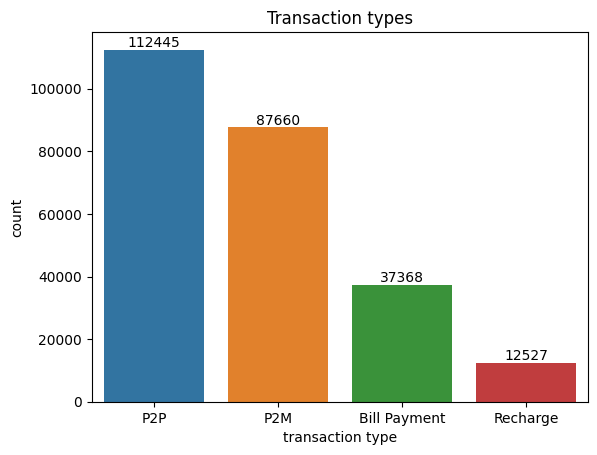

In [7]:
# transaction type analysis
ax = sns.countplot(data = df, x = "transaction type")
ax.bar_label(ax.containers[0])
plt.title("Transaction types")
plt.show()

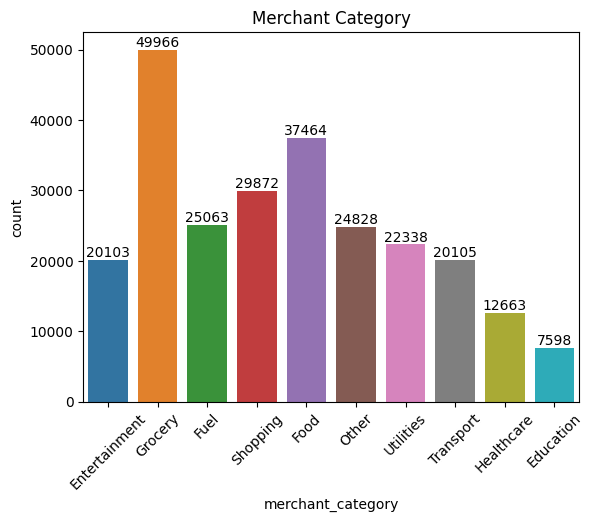

In [8]:
# merchant category analysis
ax = sns.countplot(data = df, x = "merchant_category")
ax.bar_label(ax.containers[0])
plt.title("Merchant Category")
plt.xticks(rotation=45)
plt.show()

25% Transaction amount:  288.0
Median Transaction amount:  629.0
75% Transaction amount:  1596.0
Minimum Transaction amount:  10
Maximum Transaction amount:  42099


<Axes: title={'center': 'Transaction value distribution'}, xlabel='amount (INR)'>

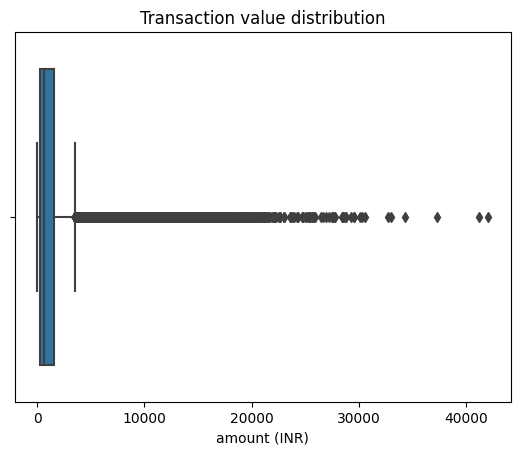

In [9]:
#transaction amount ranges
print("25% Transaction amount: ", df["amount (INR)"].quantile(0.25))
print("Median Transaction amount: ", df["amount (INR)"].median())
print("75% Transaction amount: ", df["amount (INR)"].quantile(0.75))
print("Minimum Transaction amount: ", df["amount (INR)"].min())
print("Maximum Transaction amount: ", df["amount (INR)"].max())
#print("Median Transaction amount: ", df["amount (INR)"].median())
plt.title("Transaction value distribution")
sns.boxplot(data = df, x = "amount (INR)")

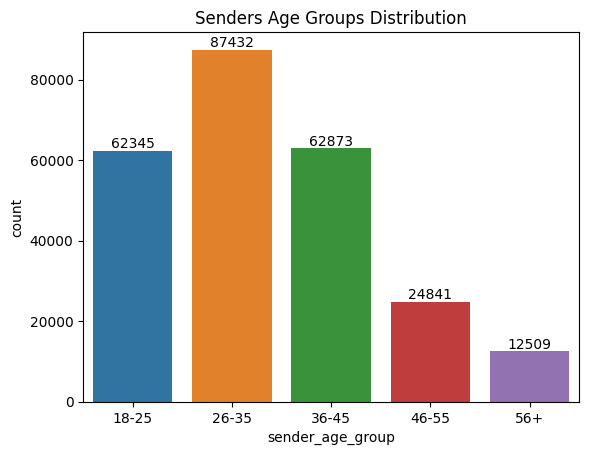

In [10]:
# senders age groups
plt.title("Senders Age Groups Distribution")
ax = sns.countplot(data = df, x = "sender_age_group", order = ["18-25", "26-35", "36-45", "46-55", "56+"])
ax.bar_label(ax.containers[0])
plt.show()

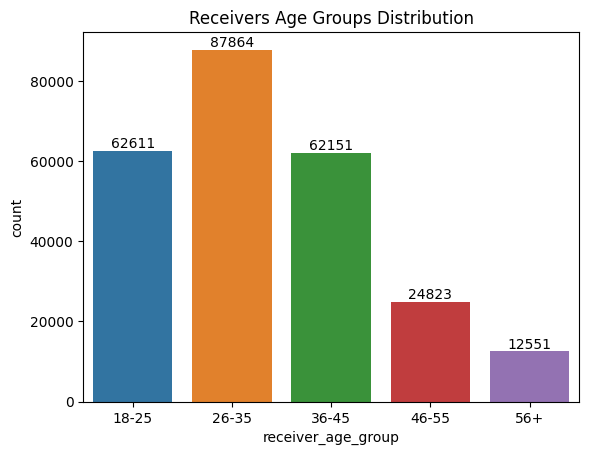

In [11]:
# receivers age groups
plt.title("Receivers Age Groups Distribution")
ax = sns.countplot(data = df, x = "receiver_age_group")
ax.bar_label(ax.containers[0])
plt.show()

% of transactions failed:  4.95


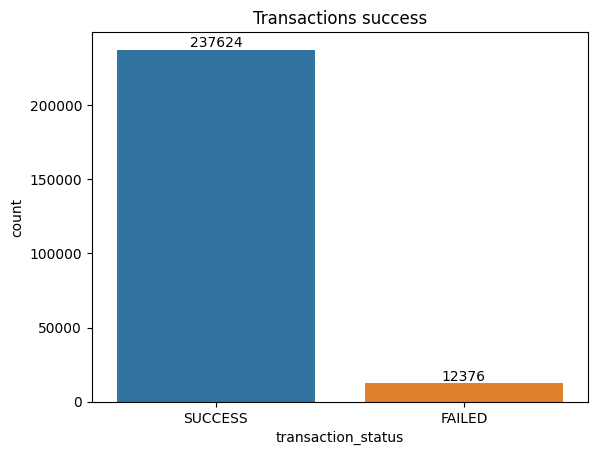

In [12]:
#transaction success
print("% of transactions failed: ", ((df["transaction_status"] == "FAILED").sum() / len(df["transaction_status"])).round(4) * 100)
plt.title("Transactions success")
ax = sns.countplot(data = df, x = "transaction_status")
ax.bar_label(ax.containers[0])
plt.show()

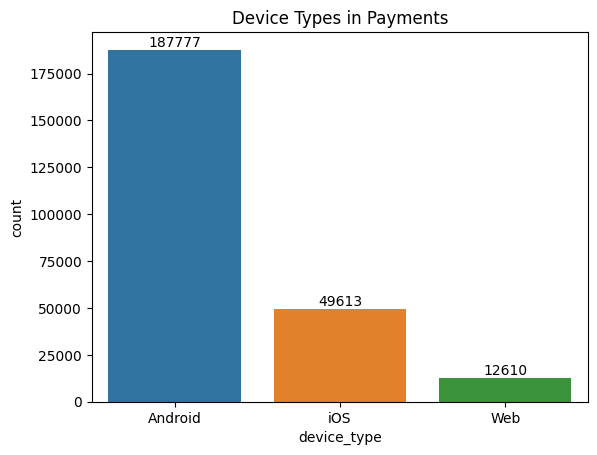

In [13]:
#device type
plt.title("Device Types in Payments")
ax = sns.countplot(data = df, x = "device_type")
ax.bar_label(ax.containers[0])
plt.show()

% of fraud transactions:  0.19


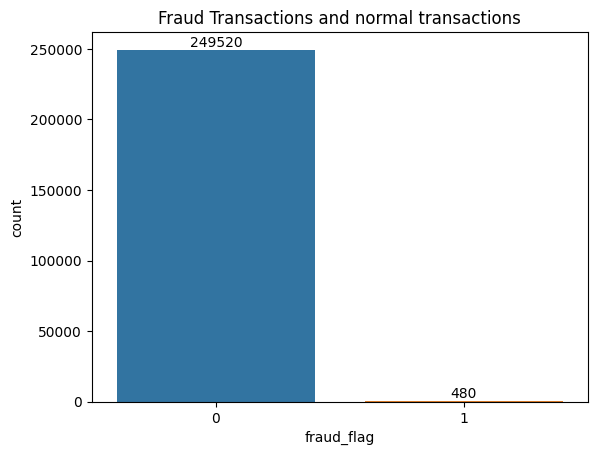

In [14]:
#fraud counts
print("% of fraud transactions: ", ((df["fraud_flag"]).sum() / len(df["fraud_flag"])).round(4) * 100)
plt.title("Fraud Transactions and normal transactions")
ax = sns.countplot(data = df, x = "fraud_flag")
ax.bar_label(ax.containers[0])
plt.show()

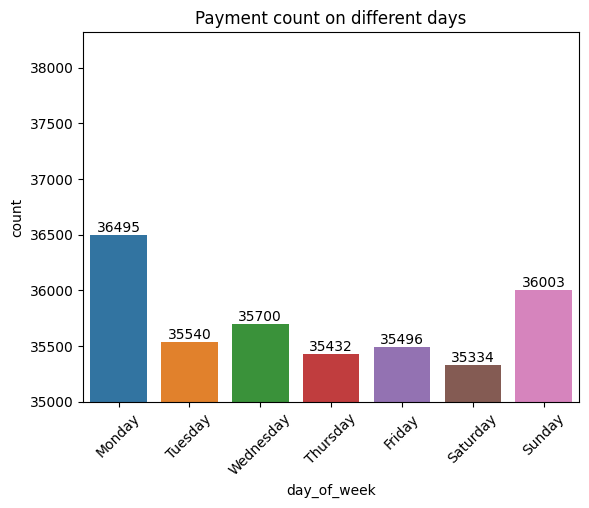

In [15]:
# days of week analysis
plt.title("Payment count on different days")
ax = sns.countplot(data = df, x = "day_of_week", order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
ax.bar_label(ax.containers[0])
plt.xticks(rotation = 45)
plt.ylim(35000)
plt.show()

# EDA - Exploratory Data Analysis
## Univariate Analysis
    1. transaction type - most payments are of P2P type followed by P2M
    2. merchent_category - Maximum payments are in **Grocery** and **Food** and least are in **Education** and **Healthcarte** highlighting most people use UPI for regular transactions and not on transcations where amount can be larger.
    3. amount (INR) - The data is highly skewed on the left side, 75% of the transactions are lower then 1600 INR, showing the use of UPI for smaller transactions only.
    4. sender_age_group - maximum number of users using UPI are between 26-35 which is the young working population of the country
    5. receiver_age_group - the same is for the receivers age group 26-35
    6. transaction_status - ~5% of the total transaction fails
    7. device_type - the most common device type is andriod, followed by ios and then web
    8. fraud_flag - a total of 0.19% transactions falls into the category of fraud
    9. day_of_week - overall the number of transaction done in entire week is almost consistent except on Sunday and Monday where there is a rise in number of transactions  
    
## Bivariate Analysis
   1. Rise or fall of number and amount of transactions overtime?
      - The number of transactions hasa remained consistent in the range of 600 - 770 and amount between 800K - 1.1M per day throughout the year
   2. Rise or fall in frauds overtime?
      - The number of frauds have remained consistent between the range of 0 - 6 With no sudden increase or decrease in it.
   3. Which merchent type has the maximum volume of transaction, and which one has max value?
      - The data shows that most of the transactions are off grocery food and shopping type indicating most of the individuals use upi for their regular transactions, while the total transactions show that most of the transactions goes into shopping, grocery, utilities, and education, however average transaction shows that maximum value of the transaction goes into education while food and grocery are not that high.
   6. Which age group is doing its expenditure at which merchent? (buying behaviour)
      - The Heat map shows individuals in the age group of 26 to 35 are doing most of their expenditure on shopping and grocery while it is distributed for the age group of 36 to 45 for utilities shopping grocery and education the older age group tend to spend not on a particular sector.
   8. Which age groups are more prone to frauds?
      - This data shows that individuals in the age group of 18 to 25 and more than 56 are most prone to the frauds while others are lesser prone.
        
   10. Which state has best infrastructure?
       - According to the Heat map we can see that Maharashtra has the best network infrastructure The rise of 5G Network can be clearly seen while the most dominant network is still 4G.
       
   12. Which bank manages the maximum volume of transactions?
       - As the pie chart shows SBI manages total 25% of the total transactions making it the bank with highest number of transactions, followed by HDFC.
         
   14. Which banks face highest number of transaction failures and frauds?
       - The absolute data shows that SBI faces The maximum number of transaction failures which can be due to the high number of transactions it do so looking at the percentage distribution we can see that yes bank has the highest number of transaction failures. As for the fraud most of the banks lie in the range of point .16 to .25 Making the fraud transaction same throughout.
  
   16. Are transaction failures related to network types?
       - This seems to show that a full due to weak Network is there rise in transaction failure and we can see that somehow the slower Internet has higher transaction failure than the faster internet. 3G network has 5.22% transaction failure while 5G has 4.86%.
  
   18. Which time of the day the maximum number of transactions take place?
       - Throughout the day the peak of UPI payments is achieved around 12 in the noon and 7 in the evening Its the highest concentrated time for upi payments.
  
   20. Are some hours more prone to transaction failures or frauds?
       - However transaction failure data shows that usually in the night from 12 to 3 A higher number of transaction failures are recorded in comparison to the transaction failures in entire day. This can be similarly seen for frauds as a higher percentage of fraud transactions can be seen from 12 in the night to 6 in the morning.
  
   22. Which type of device holder does the highest amounts of payments? (ios vs android)
       - This data however shows that all the users have almost similar type of expenditure irrespective of their devices if they have ios Android or web they are doing expenditure a little over 1300.
  
   24. Are larger transactions more prone to fraud?
       - The histogram shows that transactions between 15 to 20 thousand are more prone to fraud than the other transactions showing a range of a fraud transaction amount.
  
   26. Expenditure behaviour based on the days of week?
       - Different age groups shows a similar pattern of their expenditure throughout the week the younger population tend to spend more throughout the week while the older population tends to spend less throughout the week.
  

Min transactions  595
Max transactions  772


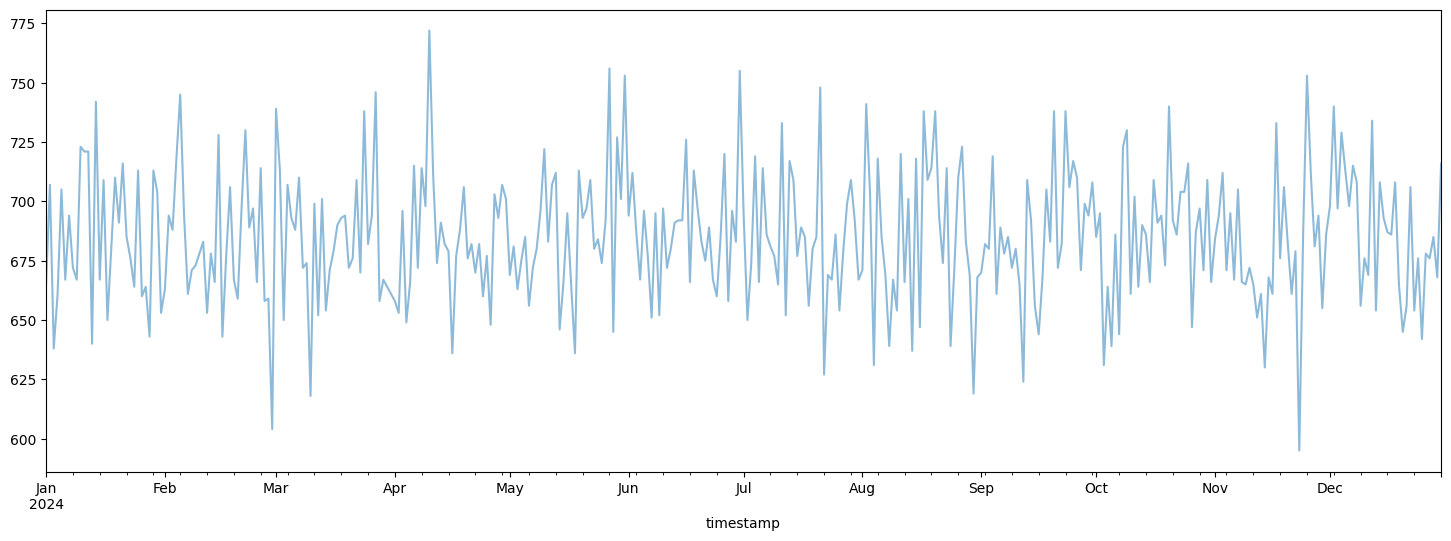

In [16]:
#number of transactions over period
transactions_over_time = df.set_index("timestamp")["transaction id"].resample("D").count().rename("Transactions")
print("Min transactions ", transactions_over_time.min())
print("Max transactions ", transactions_over_time.max())
plt.figure(figsize = (18, 6))
transactions_over_time.plot(alpha = 0.5)
plt.show()

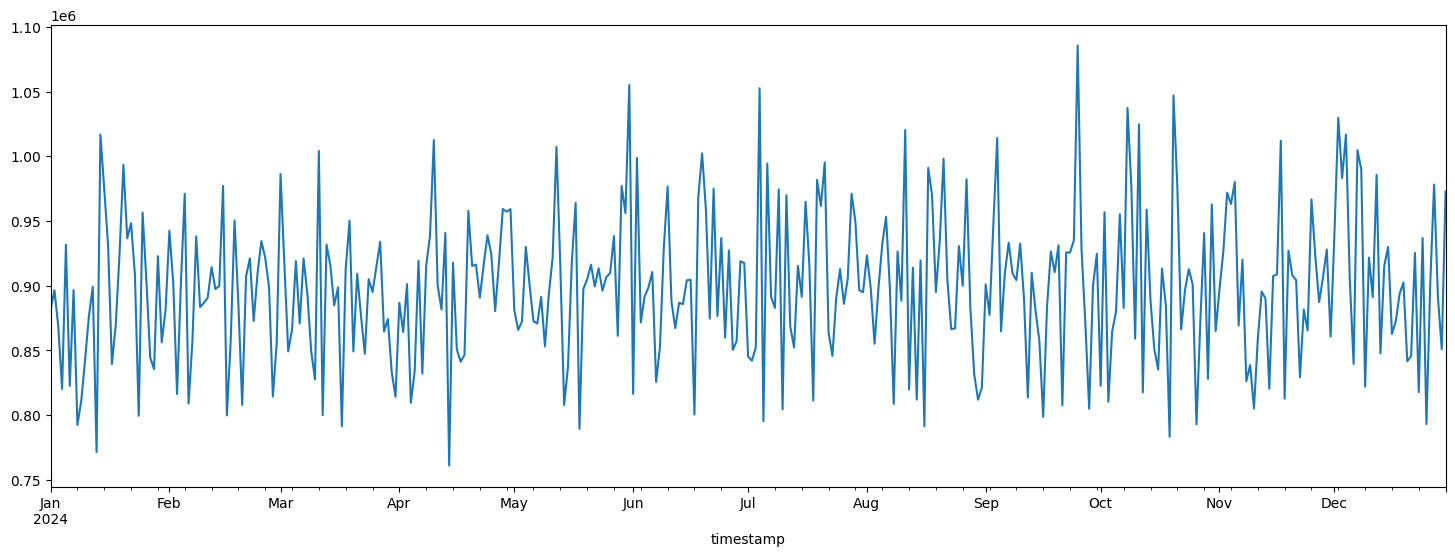

In [17]:
amount_over_time = df.set_index("timestamp")["amount (INR)"].resample("D").sum().rename("Amount")
plt.figure(figsize = (18, 6))
amount_over_time.plot()
plt.show()

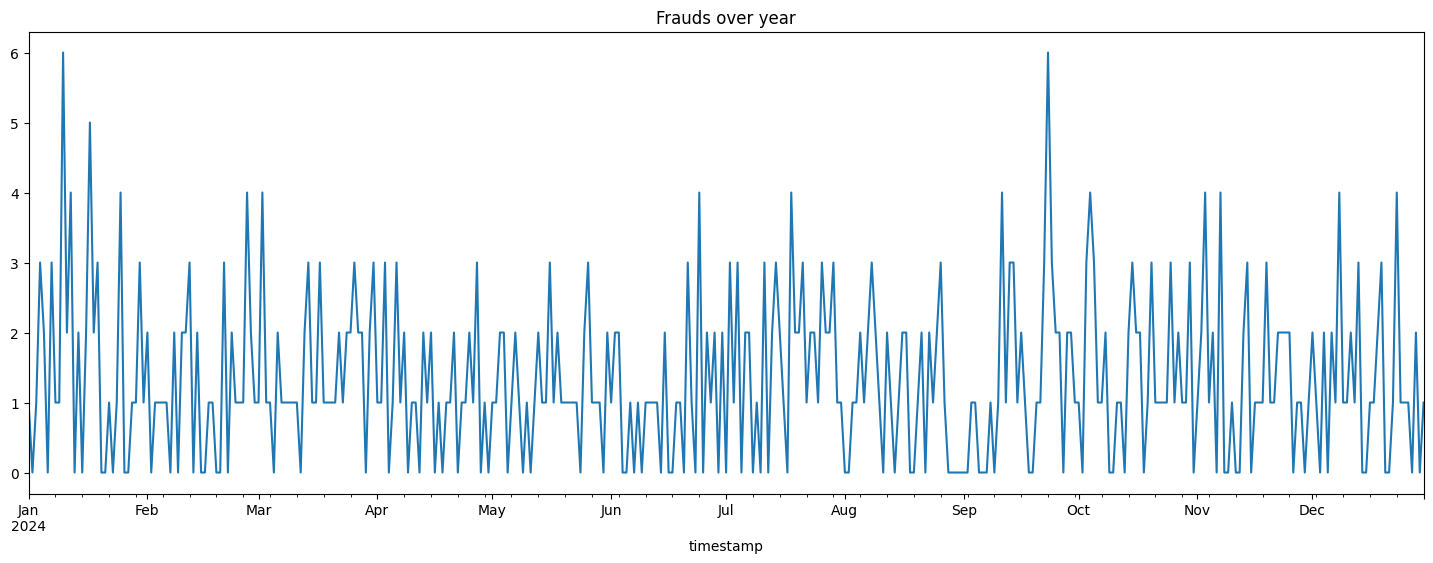

In [18]:
frauds_over_time = df.set_index("timestamp")["fraud_flag"].resample("D").sum().rename("frauds")
plt.figure(figsize = (18, 6))
plt.title("Frauds over year")
frauds_over_time.plot()
plt.show()

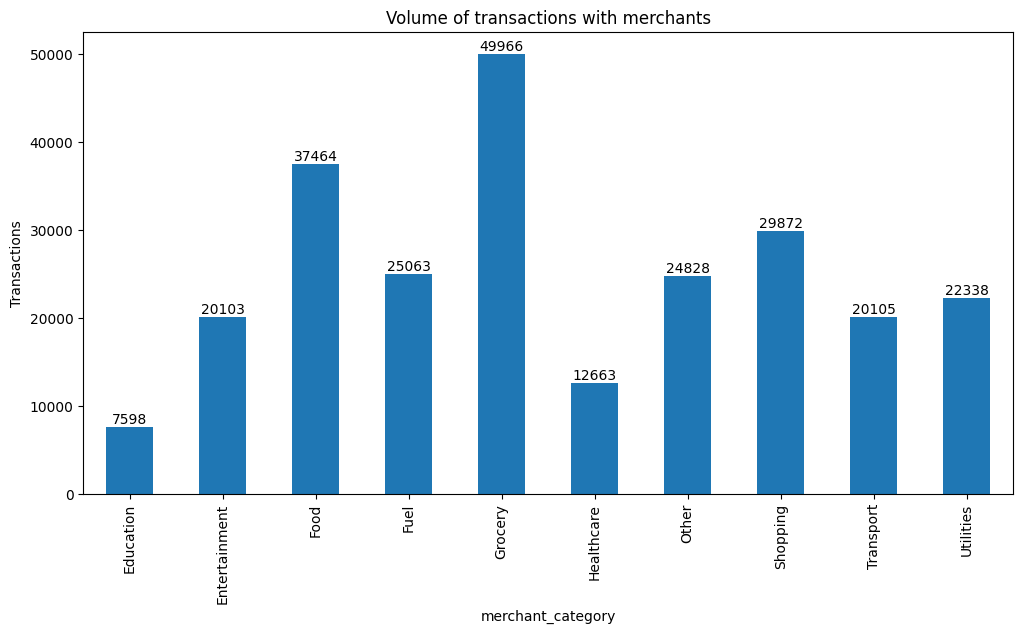

In [19]:
# merchant transaction analysis
merchant_transactions = df.groupby("merchant_category").agg(
    transactions = ("transaction id", "count"),
    total_amount = ("amount (INR)", "sum")
).reset_index()
merchant_transactions["average_transaction"] = merchant_transactions["total_amount"] / merchant_transactions["transactions"]

plt.figure(figsize = (12, 6))
plt.title("Volume of transactions with merchants")
ax = merchant_transactions.set_index("merchant_category")["transactions"].plot(kind = "bar")
ax.set_ylabel("Transactions")

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{int(height)}", (bar.get_x() + bar.get_width()/2, height), ha = "center", va = "bottom")

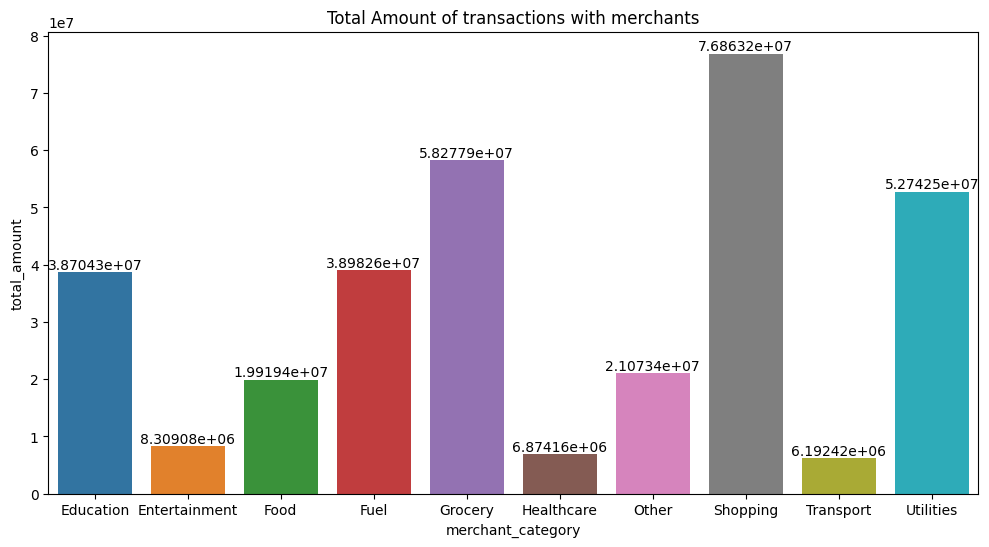

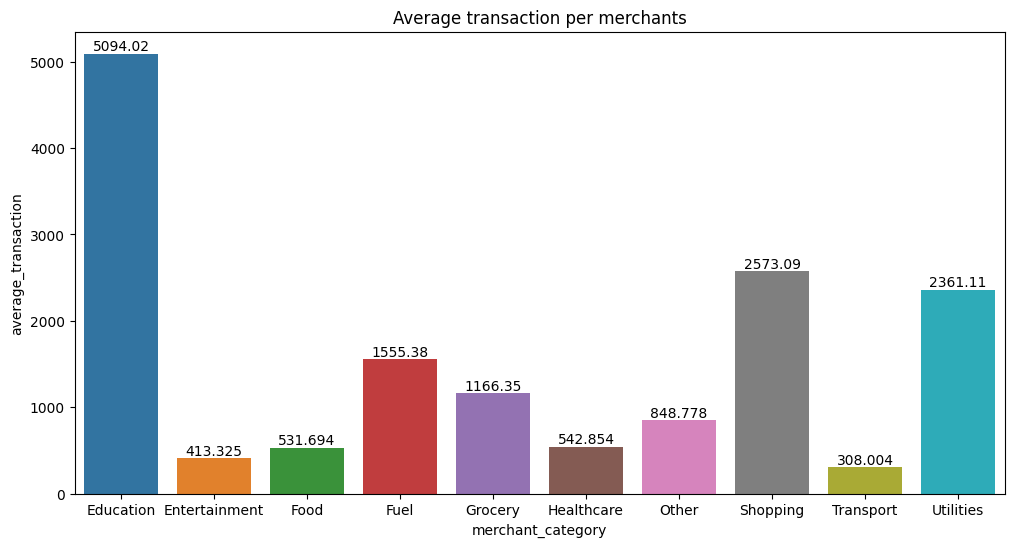

In [20]:
plt.figure(figsize = (12, 6))
plt.title("Total Amount of transactions with merchants")
ax = sns.barplot(data = merchant_transactions, x = "merchant_category", y = "total_amount")
ax.bar_label(ax.containers[0])

plt.figure(figsize = (12, 6))
plt.title("Average transaction per merchants")
ax1 = sns.barplot(data = merchant_transactions, x = "merchant_category", y = "average_transaction")
ax1.bar_label(ax1.containers[0])
plt.show()

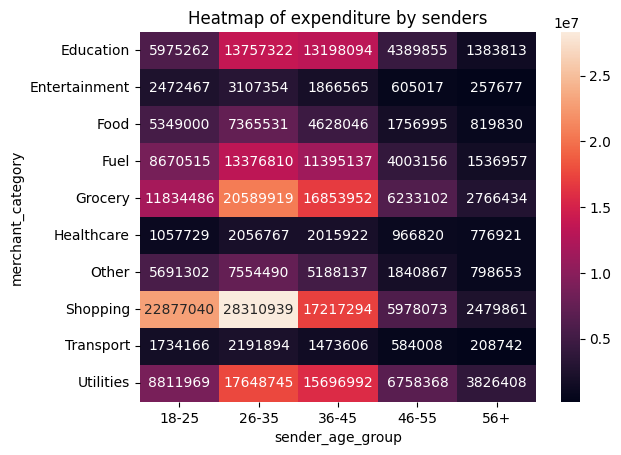

In [21]:
merchant_age_pivot = df.pivot_table(index = "merchant_category", columns = "sender_age_group", values = "amount (INR)", aggfunc = "sum", fill_value = 0)
sns.heatmap(merchant_age_pivot, annot = True, fmt = ".0f")
plt.title("Heatmap of expenditure by senders")
plt.show()

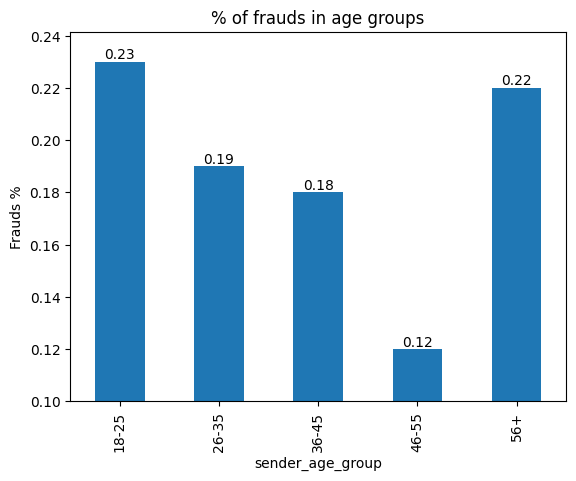

In [22]:
fraud_age = df.groupby("sender_age_group").agg(
    transactions = ("transaction id", "count"),
    fraud_transactions = ("fraud_flag", "sum")
)
fraud_age["% of frauds"] = (fraud_age["fraud_transactions"] / fraud_age["transactions"]).round(4) * 100 
ax = fraud_age["% of frauds"].plot(kind = "bar")
ax.set_ylabel("Frauds %")
plt.title("% of frauds in age groups")
plt.ylim(0.1)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{(height).round(2)}", (bar.get_x() + bar.get_width()/2, height), ha = "center", va = "bottom")

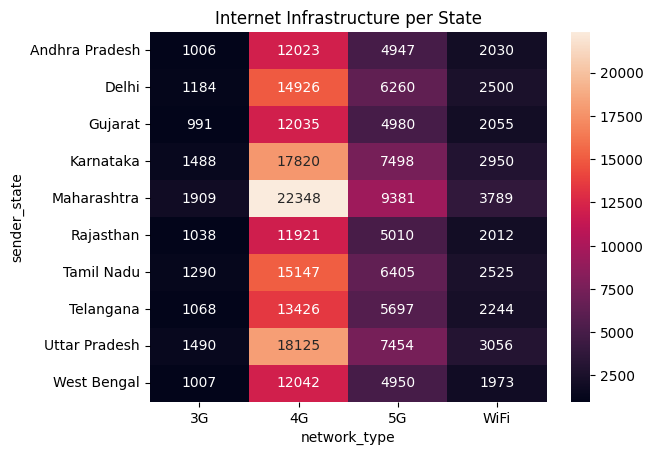

In [23]:
#state network infrastructure
state_network_pivot = df.pivot_table(index = "sender_state", columns = "network_type", values = "transaction id", aggfunc = "count", fill_value = 0)
sns.heatmap(state_network_pivot, annot = True, fmt = ".0f")
plt.title("Internet Infrastructure per State")
plt.show()

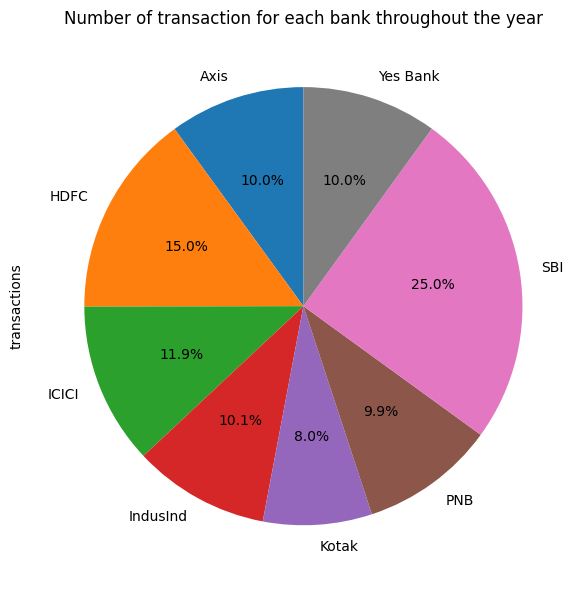

In [24]:
send = df.groupby("sender_bank").agg(
    transactions = ("transaction id", "count")
)
receive = df.groupby("receiver_bank").agg(
    transactions = ("transaction id", "count")
)
bank = receive
bank["transactions"] = bank["transactions"] + send["transactions"]

plt.figure(figsize=(12, 6))
plt.title("Number of transaction for each bank throughout the year")
bank["transactions"].plot.pie(autopct = "%1.1f%%", startangle = 90)
plt.tight_layout()
plt.show()

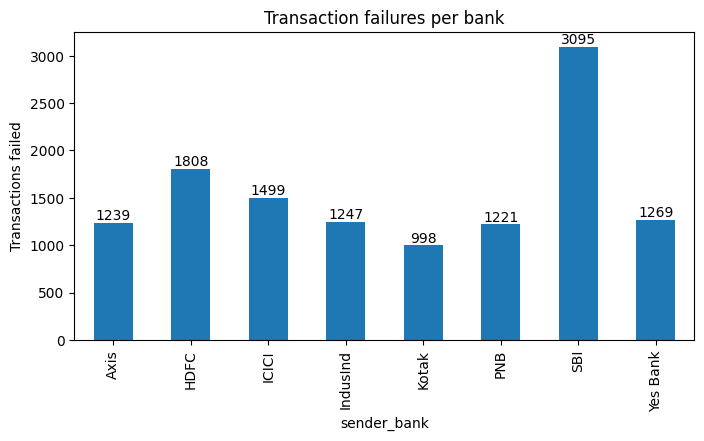

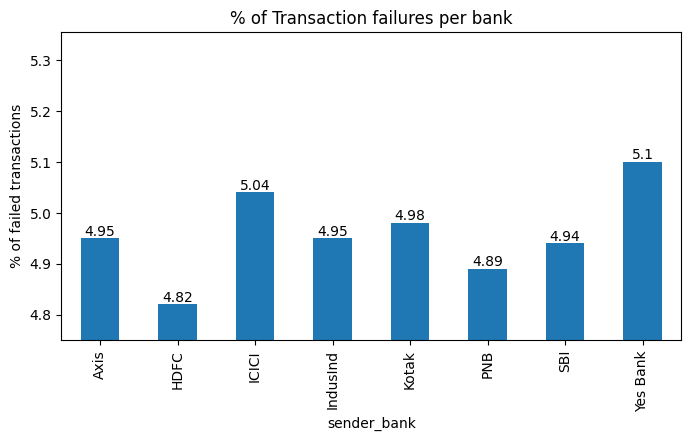

In [25]:
bank_transactions_failed = df[df["transaction_status"] == "FAILED"].groupby("sender_bank")["transaction_status"].count().reset_index()
bank_transactions_failed = bank_transactions_failed.rename(columns = {"transaction_status": "transactions_failed"})

bank_transactions_failed["total_transactions"] = df.groupby("sender_bank")["transaction_status"].count().reset_index()["transaction_status"]
bank_transactions_failed["fraud_transactions"] = df.groupby("sender_bank")["fraud_flag"].sum().reset_index()["fraud_flag"]
bank_transactions_failed["% of failed transactions"] = (bank_transactions_failed["transactions_failed"]/bank_transactions_failed["total_transactions"]).round(4) * 100
bank_transactions_failed["% of fraud transactions"] = (bank_transactions_failed["fraud_transactions"]/bank_transactions_failed["total_transactions"]).round(4) * 100
bank_transactions_failed.set_index("sender_bank", inplace = True)

plt.figure(figsize = (8, 4))
plt.title("Transaction failures per bank")
ax = bank_transactions_failed["transactions_failed"].plot(kind = "bar")
ax.set_ylabel("Transactions failed")
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{int(height)}", (bar.get_x() + bar.get_width() / 2, height), ha = "center", va = "bottom")
plt.show()

plt.figure(figsize = (8, 4))
plt.title("% of Transaction failures per bank")
ax = bank_transactions_failed["% of failed transactions"].plot(kind = "bar")
ax.set_ylabel("% of failed transactions")
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{(height).round(2)}", (bar.get_x() + bar.get_width() / 2, height), ha = "center", va = "bottom")
plt.ylim(4.75)
plt.show()


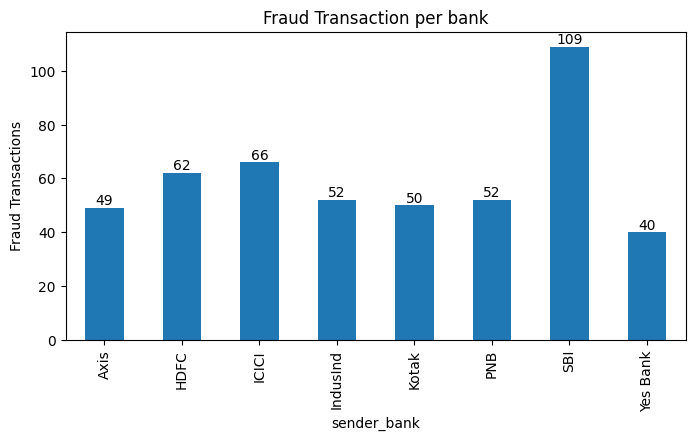

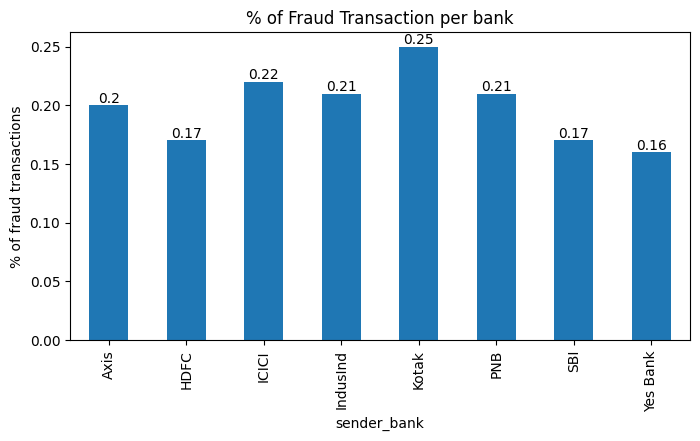

In [26]:
plt.figure(figsize = (8, 4))
plt.title("Fraud Transaction per bank")
ax = bank_transactions_failed["fraud_transactions"].plot(kind = "bar")
ax.set_ylabel("Fraud Transactions")
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{int(height)}", (bar.get_x() + bar.get_width() / 2, height), ha = "center", va = "bottom")
plt.show()

plt.figure(figsize = (8, 4))
plt.title("% of Fraud Transaction per bank")
ax = bank_transactions_failed["% of fraud transactions"].plot(kind = "bar")
ax.set_ylabel("% of fraud transactions")
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{(height).round(2)}", (bar.get_x() + bar.get_width() / 2, height), ha = "center", va = "bottom")
plt.show()

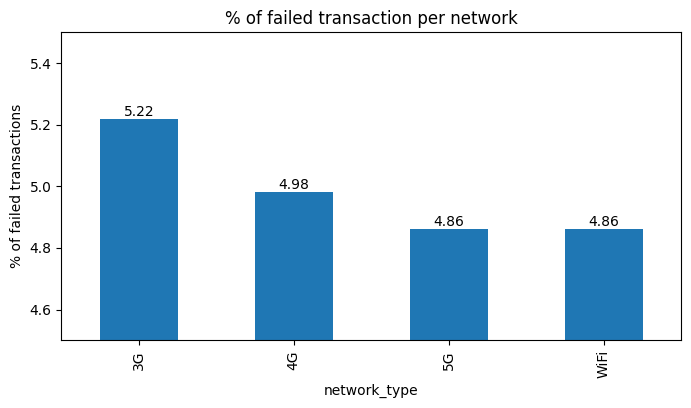

In [27]:
network_failures = df[df["transaction_status"] == "FAILED"].groupby("network_type")["transaction_status"].count().reset_index()
network_failures["total_transactions"] = df.groupby("network_type")["transaction id"].count().reset_index()["transaction id"]
network_failures["% of failed transactions"] = (network_failures["transaction_status"]/network_failures["total_transactions"]).round(4) * 100
network_failures.set_index("network_type", inplace = True)

plt.figure(figsize = (8, 4))
plt.title("% of failed transaction per network")
ax = network_failures["% of failed transactions"].plot(kind = "bar")
ax.set_ylabel("% of failed transactions")
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{(height).round(2)}", (bar.get_x() + bar.get_width() / 2, height), ha = "center", va = "bottom")
plt.ylim(4.5, 5.5)
plt.show()

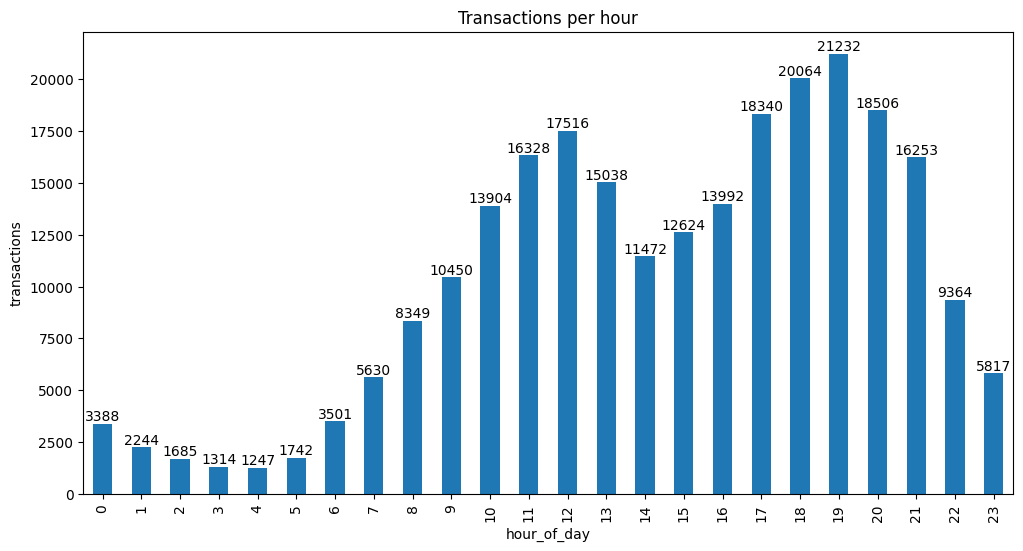

In [28]:
hour_transactions = df.groupby("hour_of_day")["transaction id"].count()
plt.figure(figsize = (12, 6))
plt.title("Transactions per hour")
ax = hour_transactions.plot(kind = "bar")
ax.set_ylabel("transactions")
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{int(height)}", (bar.get_x() + bar.get_width() / 2, height), ha = "center", va = "bottom")
plt.show()

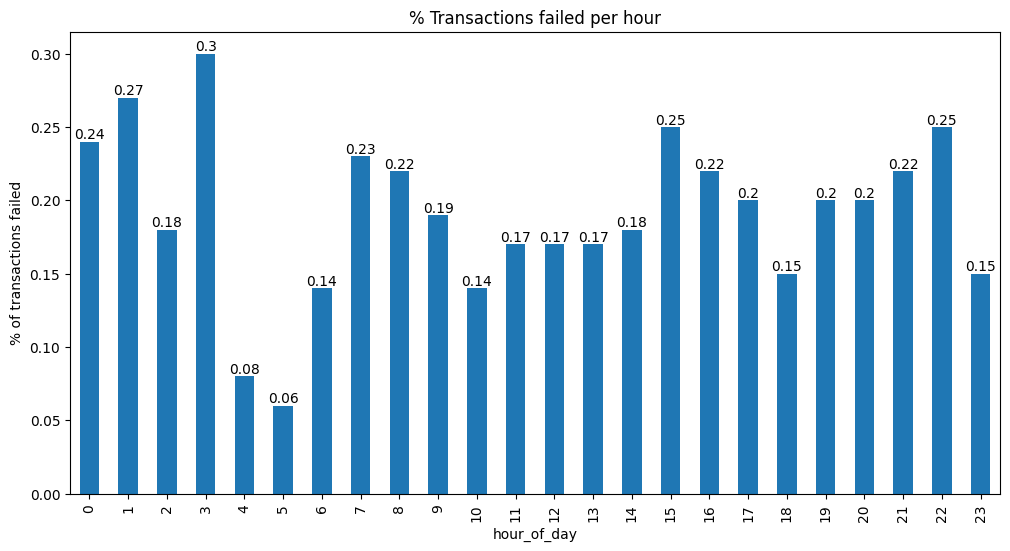

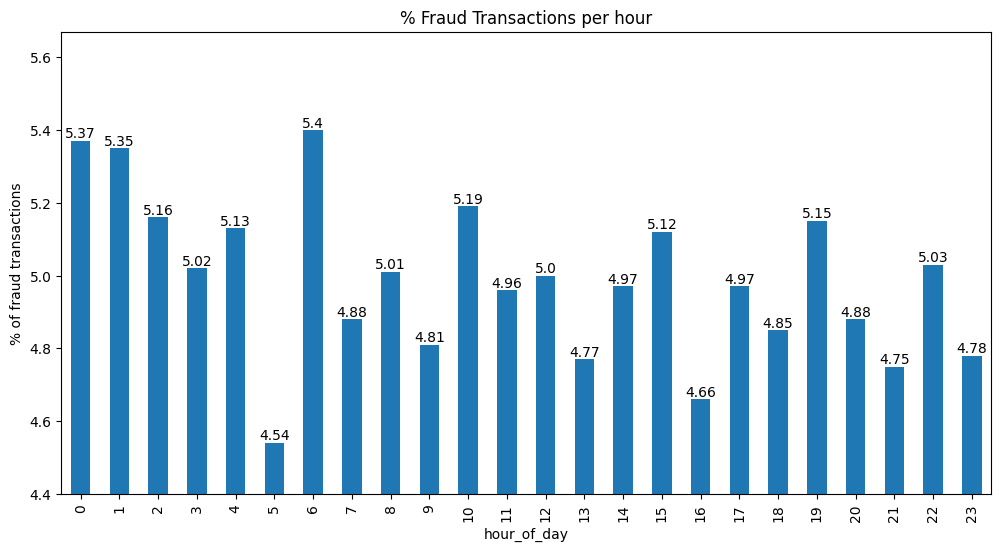

In [29]:
hourly_analysis = df[df["transaction_status"] == "FAILED"].groupby("hour_of_day")["transaction_status"].count().reset_index()
hourly_analysis = hourly_analysis.rename(columns = {"transaction_status" : "transactions_failed"})
hourly_analysis["fraud_transactions"] = df.groupby("hour_of_day")["fraud_flag"].sum().reset_index()["fraud_flag"]
hourly_analysis["total_transactions"] = hour_transactions.reset_index()["transaction id"]
hourly_analysis["% fraud transactions"] = (hourly_analysis["transactions_failed"] / hourly_analysis["total_transactions"]).round(4) * 100
hourly_analysis["% failed transactions"] = (hourly_analysis["fraud_transactions"] / hourly_analysis["total_transactions"]).round(4) * 100
hourly_analysis.set_index("hour_of_day", inplace = True)

plt.figure(figsize = (12, 6))
plt.title("% Transactions failed per hour")
ax = hourly_analysis["% failed transactions"].plot(kind = "bar")
ax.set_ylabel("% of transactions failed")
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{(height).round(2)}", (bar.get_x() + bar.get_width() / 2, height), ha = "center", va = "bottom")
plt.show()

plt.figure(figsize = (12, 6))
plt.title("% Fraud Transactions per hour")
ax = hourly_analysis["% fraud transactions"].plot(kind = "bar")
ax.set_ylabel("% of fraud transactions")
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f"{(height).round(2)}", (bar.get_x() + bar.get_width() / 2, height), ha = "center", va = "bottom")
plt.ylim(4.4)
plt.show()

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

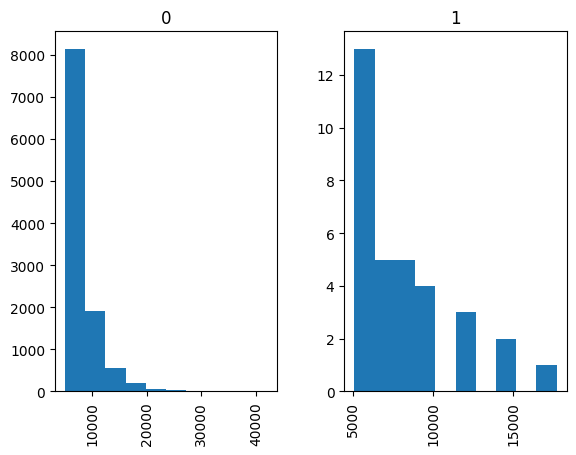

In [30]:
df[df["amount (INR)"] >= 5000].hist(column = "amount (INR)", by = "fraud_flag")

[Text(0, 0, '1313.98'), Text(0, 0, '1300.81'), Text(0, 0, '1306.1')]

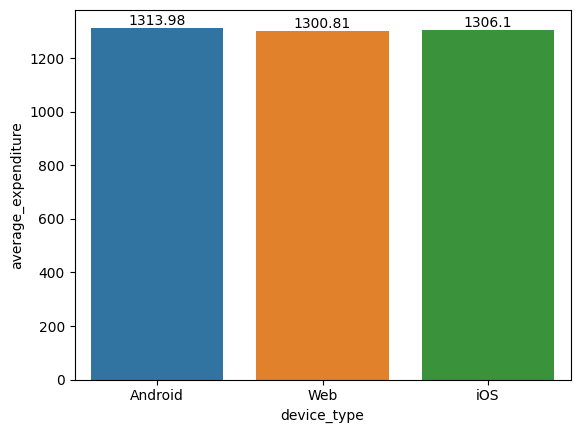

In [31]:
device_expenditure = df.groupby("device_type").agg(
    transactions = ("transaction id", "count"),
    expenditure = ("amount (INR)", "sum")
).reset_index()
device_expenditure["average_expenditure"] = device_expenditure["expenditure"] / device_expenditure["transactions"]
ax = sns.barplot(data = device_expenditure, x = "device_type", y = "average_expenditure")
ax.bar_label(ax.containers[0])

<Axes: xlabel='sender_age_group', ylabel='day_of_week'>

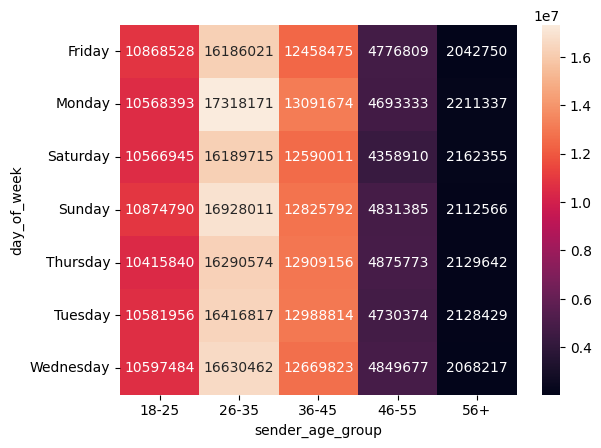

In [32]:
expenditure_behaviour_pivot = df.pivot_table(index = "day_of_week", columns = "sender_age_group", values = "amount (INR)", aggfunc = "sum", fill_value = "0")
sns.heatmap(expenditure_behaviour_pivot, annot = True, fmt = ".0f")